# Project 1

Dana Sela

In [2]:
# Prepping the system and data.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

path_neural  = '/Users/danasela/Desktop/Bar Ilan/Second Year/Semester B/Signal Processing/Project 1/Neural_data.csv'
path_spikes = '/Users/danasela/Desktop/Bar Ilan/Second Year/Semester B/Signal Processing/Project 1/spike_trains.csv'
df_neural = pd.read_csv(path_neural)
df_spikes = pd.read_csv(path_spikes)

### Part 1: Sampling Theorem: Nyquist frequency, Aliasing, Quantization

**1.A - Dividing the signal into different parts and plotting each of them in a seperate figure.**

In [3]:
# Extract the neural signal and define the time vector.
data = df_neural['ΔF/F (%)'].values
HZ = 50           # Sampling frequency in Hz.
duration = 30     # Total duration in seconds.
t = np.arange(len(data)) / HZ

# Extract the noise period (0 to 9 seconds).
noise_mask = (t >= 0) & (t < 9)
noise_part = data[noise_mask]
t_noise = t[noise_mask]

# Extract the stimulus period (12 to 30 seconds).
stim_mask = (t >= 12) & (t <= 30)
stim_part = data[stim_mask]
t_stim = t[stim_mask]

Plot the whole signal

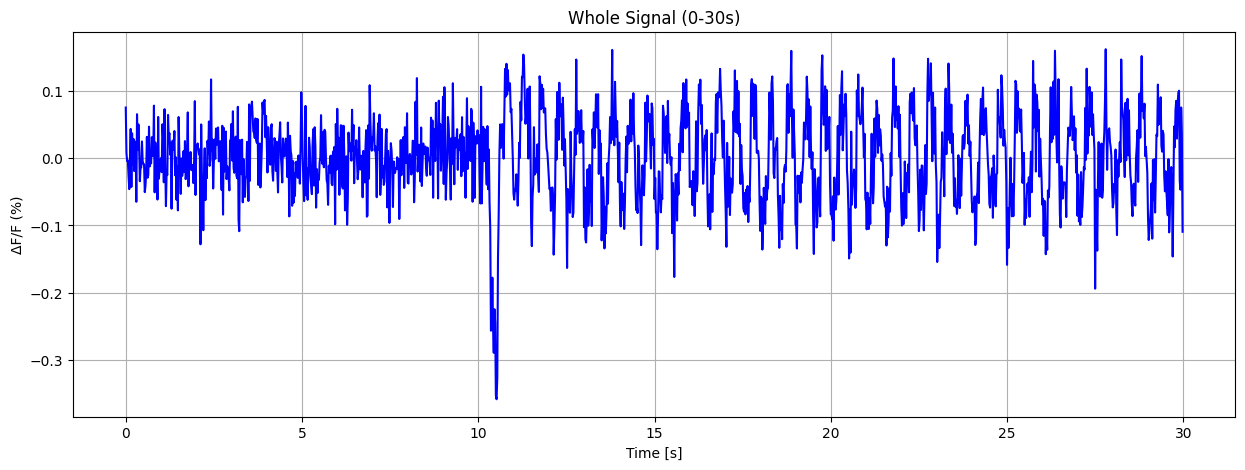

In [4]:
plt.figure(figsize=(15, 5))

# Plot the entire signal.
plt.plot(t, data, color='blue')

# Add titles and lables.
plt.title('Whole Signal (0-30s)')
plt.xlabel('Time [s]')
plt.ylabel('ΔF/F (%)')
plt.grid(True)

Plot the noise signal

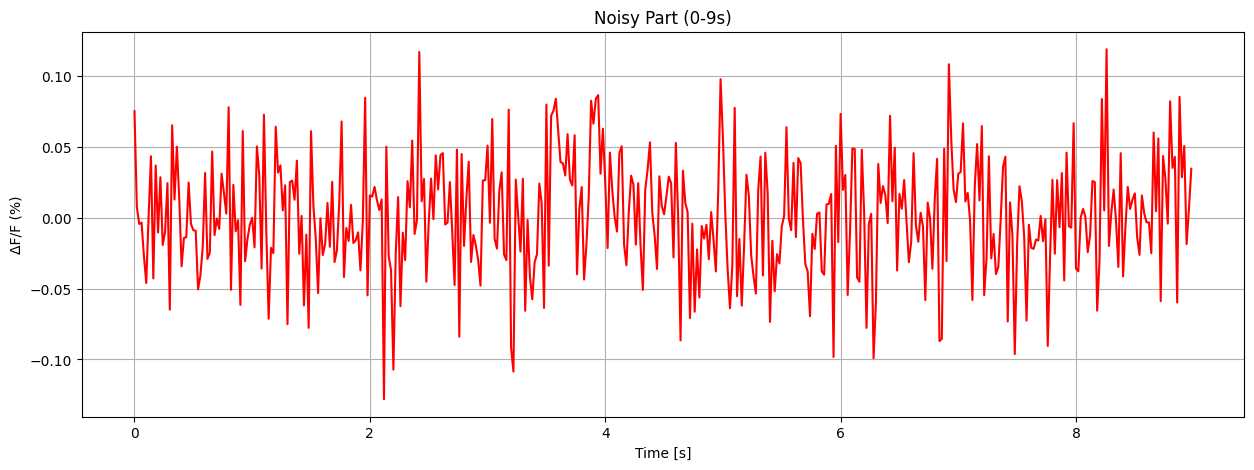

In [5]:
plt.figure(figsize=(15, 5))

# Plot the noise part of the signal.
plt.plot(t_noise, noise_part, color='red')

# Add titles and lables.
plt.title('Noisy Part (0-9s)')
plt.xlabel('Time [s]')
plt.ylabel('ΔF/F (%)')
plt.grid(True)

Plot the stimulus signal

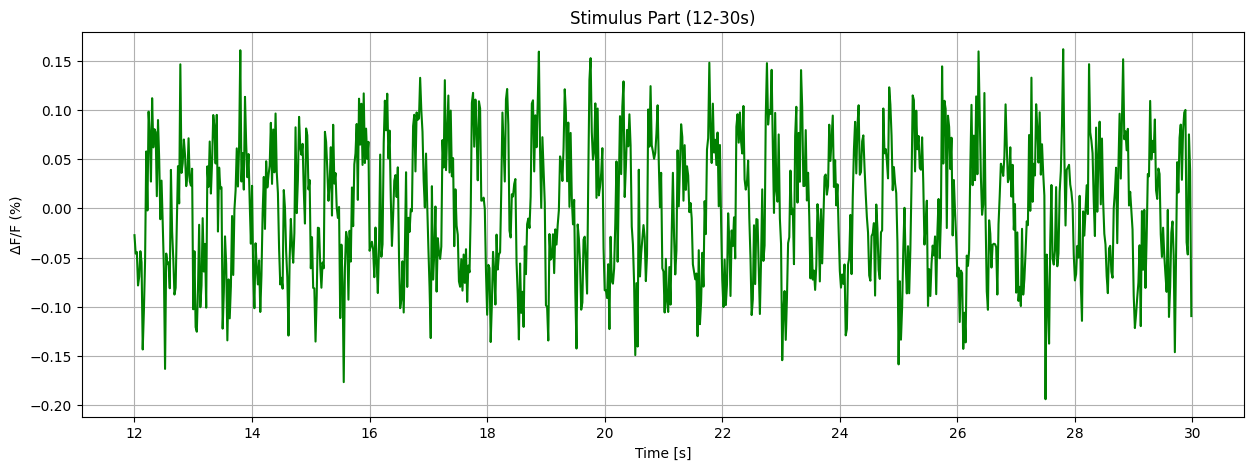

In [6]:
plt.figure(figsize=(15, 5))

# Define and apply custom x-axis ticks from 12s to 30s in steps of 2s.
ticks = np.arange(12, 31, 2)
plt.xticks(ticks)

# Plot the stimulus part of the signal.
plt.plot(t_stim, stim_part, color='green')

# Add titles and lables.
plt.title('Stimulus Part (12-30s)')
plt.xlabel('Time [s]')
plt.ylabel('ΔF/F (%)')
plt.grid(True)

**1.B - Manually Resampling**

Resampling at 25 Hz

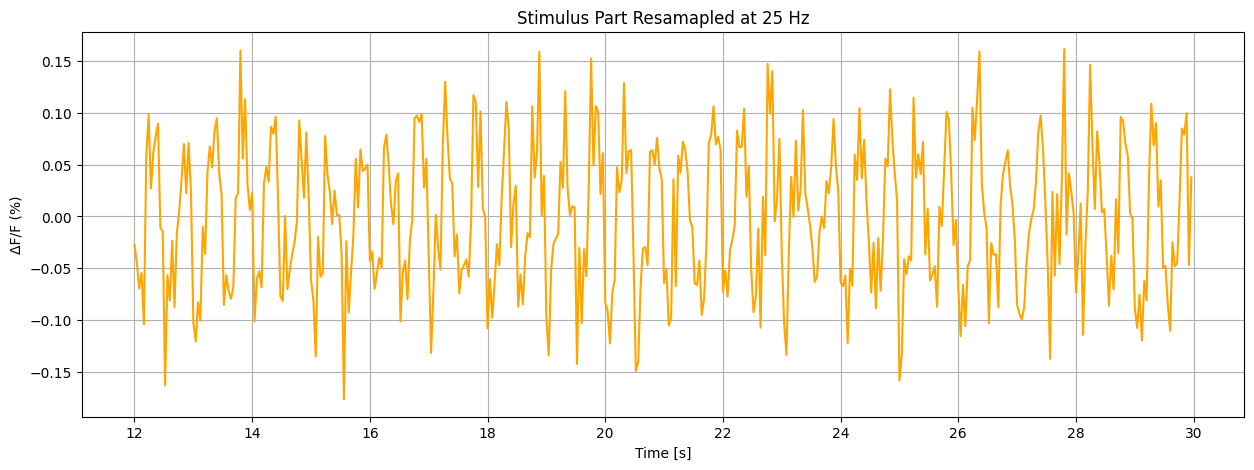

In [7]:
# Downsample the signal from 50 Hz to 25 Hz by taking every 2nd data point.
resampled_25 = stim_part[::2]

# Downsample the time vector as well.
t_25 = t_stim[::2]

# Create a new figure and apply custom x-axis ticks.
plt.figure(figsize=(15, 5))
plt.xticks(ticks)

# Plot the resampled 25 Hz signal.
plt.plot(t_25, resampled_25, color='orange')

# Add titles and lables.
plt.title('Stimulus Part Resamapled at 25 Hz')
plt.xlabel('Time [s]')
plt.ylabel('ΔF/F (%)')
plt.grid(True)

Resampling at 10 Hz

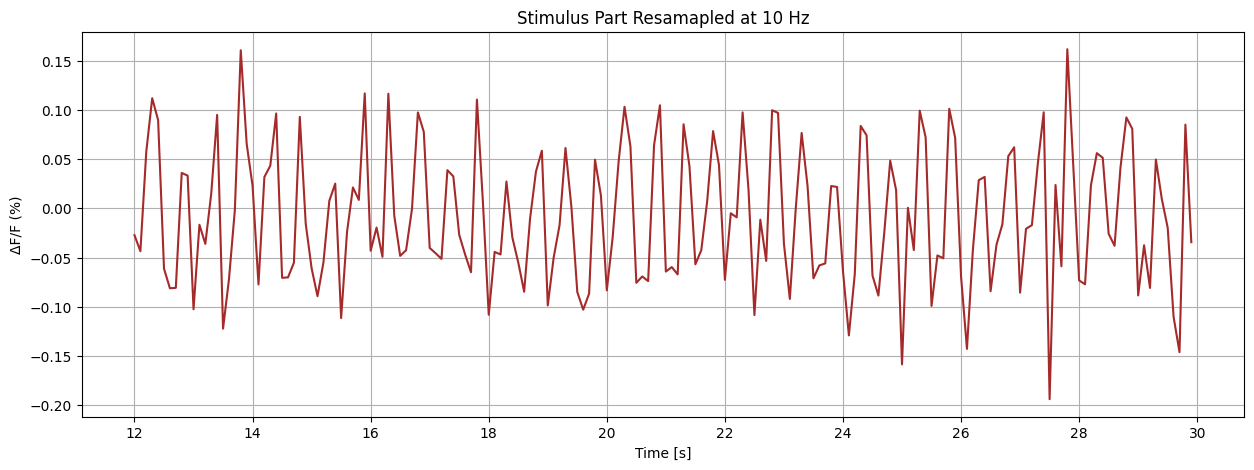

In [8]:
# Downsample the signal from 50 Hz to 10 Hz by taking every 5th data point.
resampled_10 = stim_part[::5]

# Downsample the time vector as well.
t_10 = t_stim[::5]

# Create a new figure and apply custom x-axis ticks.
plt.figure(figsize=(15, 5))
plt.xticks(ticks)

# Plot the resampled 10 Hz signal.
plt.plot(t_10, resampled_10, color='brown')

# Add titles and lables.
plt.title('Stimulus Part Resamapled at 10 Hz')
plt.xlabel('Time [s]')
plt.ylabel('ΔF/F (%)')
plt.grid(True)

Resampling at 3.33 Hz

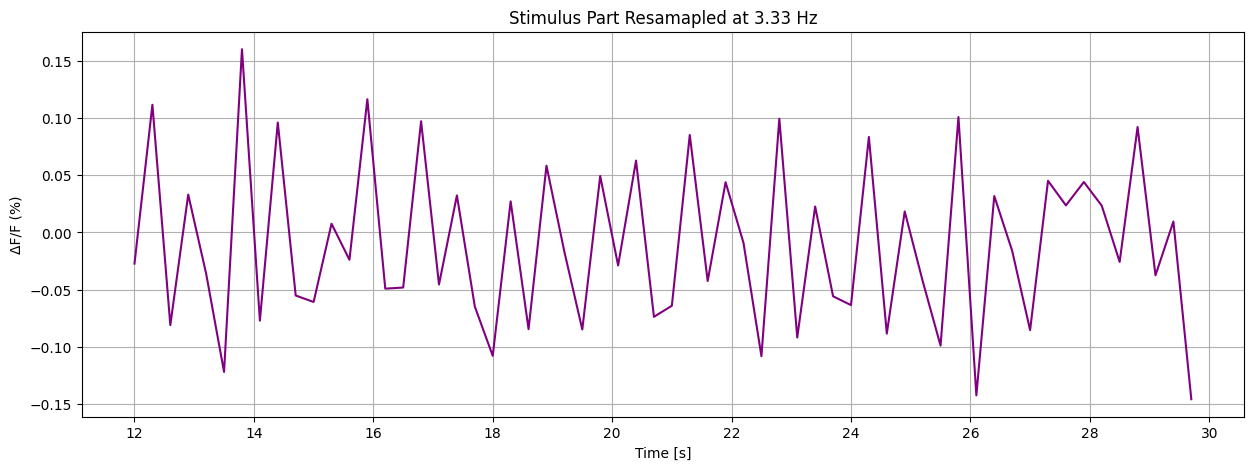

In [9]:
# Downsample the signal from 50 Hz to 3.33 Hz by taking every 15th data point.
resampled_3_33 = stim_part[::15]

# Downsample the time vector as well.
t_3_33 = t_stim[::15]

# Create a new figure and apply custom x-axis ticks.
plt.figure(figsize=(15, 5))
plt.xticks(ticks)

# Plot the resampled 3.33 Hz signal.
plt.plot(t_3_33, resampled_3_33, color='purple')

# Add titles and lables.
plt.title('Stimulus Part Resamapled at 3.33 Hz')
plt.xlabel('Time [s]')
plt.ylabel('ΔF/F (%)')
plt.grid(True)

### Part 2: Noise Reduction
**2.1 - SNRrms Calculation**

In [10]:
# Method 1: root of power ratio.
# Calculate the total power during the stimulus period (including noise).
power_signal = np.mean(stim_part**2)

# Calculate the power during the noise period.
power_noise = np.mean(noise_part**2)

# Pure stimulus power =  signal power - noise power.
power_stim = power_signal - power_noise

# Calculate the square root of the power ratio.
snr_method_1 = np.sqrt(power_stim / power_noise)
print(f"SNR Method 1 (power ratio): {snr_method_1}")

# Method 2: mean of signal / STD of noise.
snr_method_2 = np.mean(stim_part) / np.std(noise_part)
print(f"SNR Method 2 (signal mean/noise STD): {snr_method_2}")

SNR Method 1 (power ratio): 1.3375628065932543
SNR Method 2 (signal mean/noise STD): -0.023089450715801853


**2.2 - Reducing the noise**

--- Averaging 2 points: ---
New SNR: 1.8021
Improvement Factor: 1.35x (theoretical expectation: 1.41x)


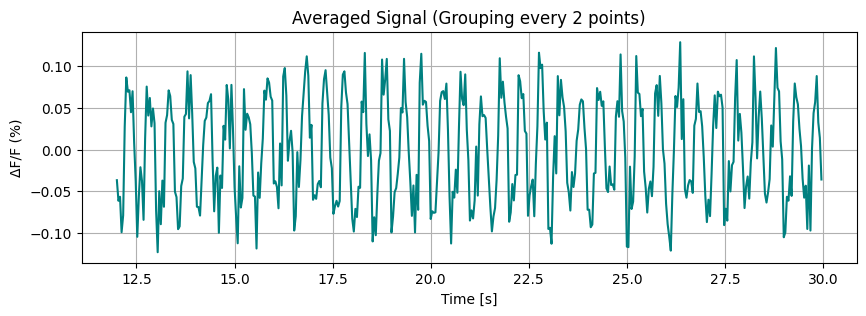

--- Averaging 3 points: ---
New SNR: 2.1533
Improvement Factor: 1.61x (theoretical expectation: 1.73x)


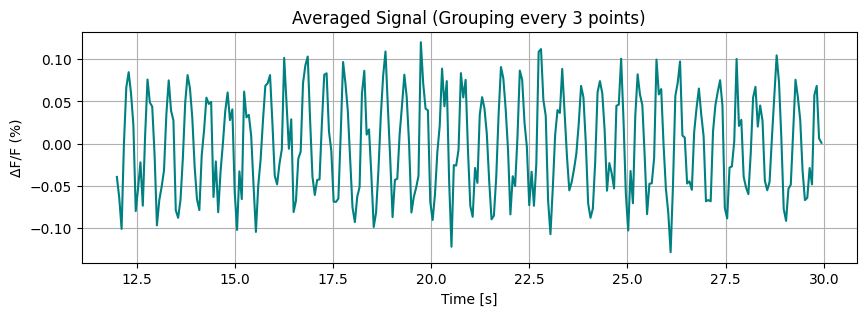

--- Averaging 5 points: ---
New SNR: 2.4823
Improvement Factor: 1.86x (theoretical expectation: 2.24x)


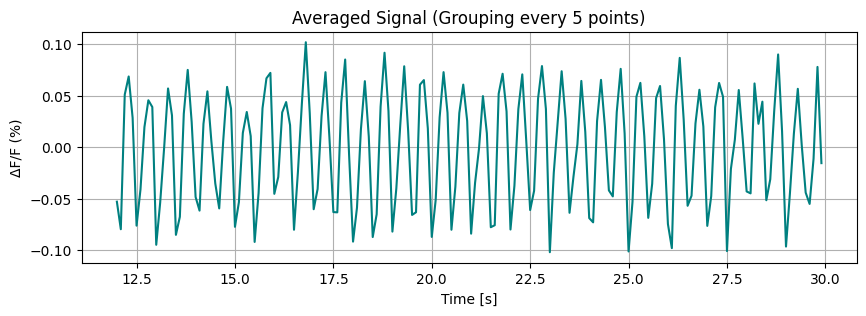

In [11]:
# Store the original SNR to calculate the improvement later.
origin_snr = snr_method_1
window_sizes = [2, 3, 5]

for w in window_sizes:
  # Truncate the stimulus array length to be divisible by current window size.
  stim_new_len = (len(stim_part) // w) * w
  stim_arr = stim_part[:stim_new_len]

  # Reshape into blocks of the window size and calculate the mean of each block.
  avg_stim = np.mean(stim_arr.reshape(-1, w), axis=1)

  # Repeat the same truncation and averaging process for the noise part.
  noise_new_len = (len(noise_part) // w) * w
  noise_arr = noise_part[:noise_new_len]
  avg_noise = np.mean(noise_arr.reshape(-1, w), axis=1)

  # Create the downsampled time vector.
  t_avg = t_stim[:stim_new_len:w]

  # Calculate power for the values.
  signal_power = np.mean(avg_stim**2)
  noise_power = np.mean(avg_noise**2)

  # Calculate the new SNR and compare it to the original one.
  new_snr = np.sqrt((signal_power - noise_power) / noise_power)
  improvement = new_snr / origin_snr

  # According to theory, averaging N points improves SNR by sqrt(N).
  theoretical = np.sqrt(w)

  print(f"--- Averaging {w} points: ---")
  print(f"New SNR: {new_snr:.4f}")
  print(f"Improvement Factor: {improvement:.2f}x (theoretical expectation: {theoretical:.2f}x)")

  # Plot the averaged signal.
  plt.figure(figsize=(10, 3))
  plt.plot(t_avg, avg_stim, color='teal')
  plt.title(f'Averaged Signal (Grouping every {w} points)')
  plt.xlabel('Time [s]')
  plt.ylabel('ΔF/F (%)')
  plt.grid(True)
  plt.show()

**2.3 - Reduced signal by 20-points kernel**

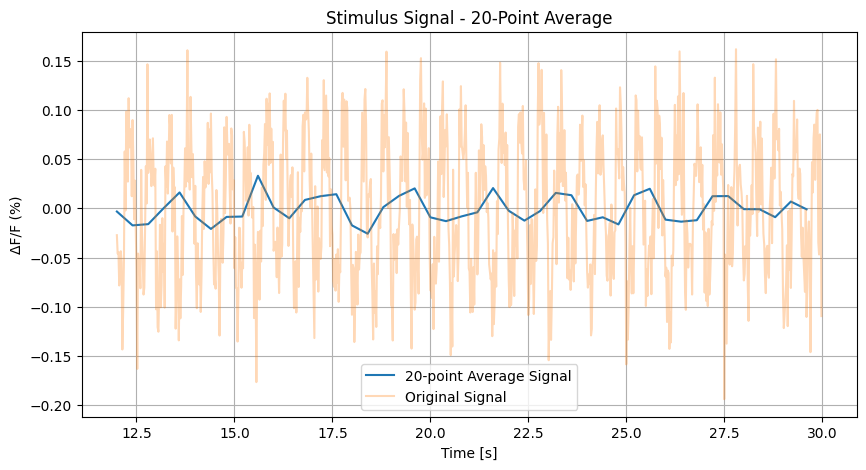

In [12]:
window = 20

# Truncate the stimulus array length to be divisible by window size.
stim_trunc_len = (len(stim_part) // window) * window
stim_truncated = stim_part[:stim_trunc_len]

# Reshape the data into blocks of 20 and calculate the mean for each block.
avg_stim_20 = np.mean(stim_truncated.reshape(-1, window), axis=1)

# Downsample the time vector.
t_avg_20 = t_stim[:stim_trunc_len:window]

plt.figure(figsize=(10, 5))

# Plot the new averaged signal.
plt.plot(t_avg_20, avg_stim_20, label='20-point Average Signal')

# Plot the original signal in the background.
plt.plot(t_stim, stim_part, alpha=0.3, label='Original Signal')

# Add titles, labels and legend.
plt.title('Stimulus Signal - 20-Point Average')
plt.xlabel('Time [s]')
plt.ylabel('ΔF/F (%)')
plt.legend()
plt.grid(True)
plt.show()

**2.4 - Rectangular Kernel Smoothing (size 3, twice)**

In [13]:
# Create a rectangular kernel (size 3).
kernel_size = 3
rect_kernel = np.ones(kernel_size) / kernel_size

# Apply the kernel twice to smooth the signal.
smooth_1 = np.convolve(stim_part, rect_kernel, mode='same')
smooth_2 = np.convolve(smooth_1, rect_kernel, mode='same')

**2.5 - Triangular smoothing (size 5)**

In [14]:
# Create a triangular kernel (weighted moving average).
tri_weights = np.array([1, 2, 3, 2, 1])
tri_kernel = tri_weights / np.sum(tri_weights)

# Apply the kernel to the original signal.
smooth_tri = np.convolve(stim_part, tri_kernel, mode='same')

**2.6 - Comparing Different Smoothing Kernels**

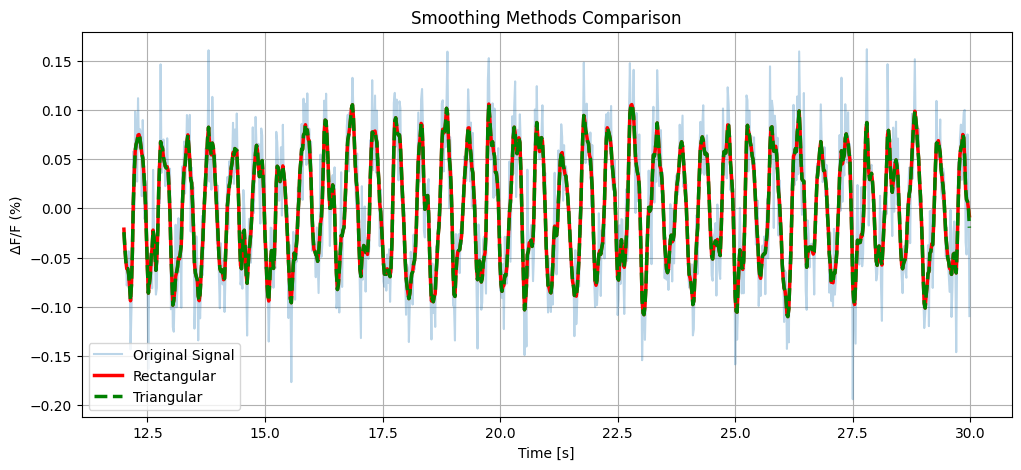

In [15]:
plt.figure(figsize=(12, 5))

# Plot the original signal in the background (transparent).
plt.plot(t_stim, stim_part, alpha=0.3, linewidth=1.5, label='Original Signal')

# Plot the smoothed signals (Triangular is dashed).
plt.plot(t_stim, smooth_2, color='red', linewidth=2.5, label='Rectangular')
plt.plot(t_stim, smooth_tri, color='green', linewidth=2.5, linestyle='--', label='Triangular')

plt.title('Smoothing Methods Comparison')
plt.xlabel('Time [s]')
plt.ylabel('ΔF/F (%)')
plt.legend()
plt.grid(True)
plt.show()

### Part 3.1: Spike Train Analysis

**3.1.A - Mean Firing Rate**

In [16]:
# Calculate total spikes per trial by summing all columns.
spike_count = df_spikes.drop(columns=['trial_neuron']).sum(axis=1)

# Convert total spike counts to firing rate (Hz).
firing_rates = spike_count / duration     # duration = 30 [s].

# Extract the neuron letter from the string format.
df_spikes['neuron'] = df_spikes['trial_neuron'].apply(lambda x: str(x).split('_')[1])

# Add the firing rates to the array and calculate the average per neuron.
df_spikes['firing_rate'] = firing_rates
mean_rates = df_spikes.groupby('neuron')['firing_rate'].mean()

print("--- Mean Firing Rates (Hz) ---")
print(mean_rates)

--- Mean Firing Rates (Hz) ---
neuron
A     11.670333
B     42.550000
C    100.000000
D     49.984333
E     28.679000
Name: firing_rate, dtype: float64


**3.1.B - Fano Factor**

In [17]:
# Extract the first 1 second columns (1000 ms).
window_data = df_spikes.iloc[:, 1:1001]

# Count the total number of spikes in this window for each trial.
df_spikes['counts_1sec'] = window_data.sum(axis=1)

# Calculate variance and mean of the spike counts for each neuron.
results = df_spikes.groupby('neuron')['counts_1sec'].agg(['var', 'mean'])

# Fano Factor = Variance / Mean.
results['Fano_Factor'] = results['var'] / results['mean']

print("--- Fano Factor for the first window ---")
print(results['Fano_Factor'])

--- Fano Factor for the first window ---
neuron
A    0.986133
B    0.574943
C    0.000000
D    0.010218
E    6.653800
Name: Fano_Factor, dtype: float64


**3.1.D - ISI distribution (neurons A, B)**

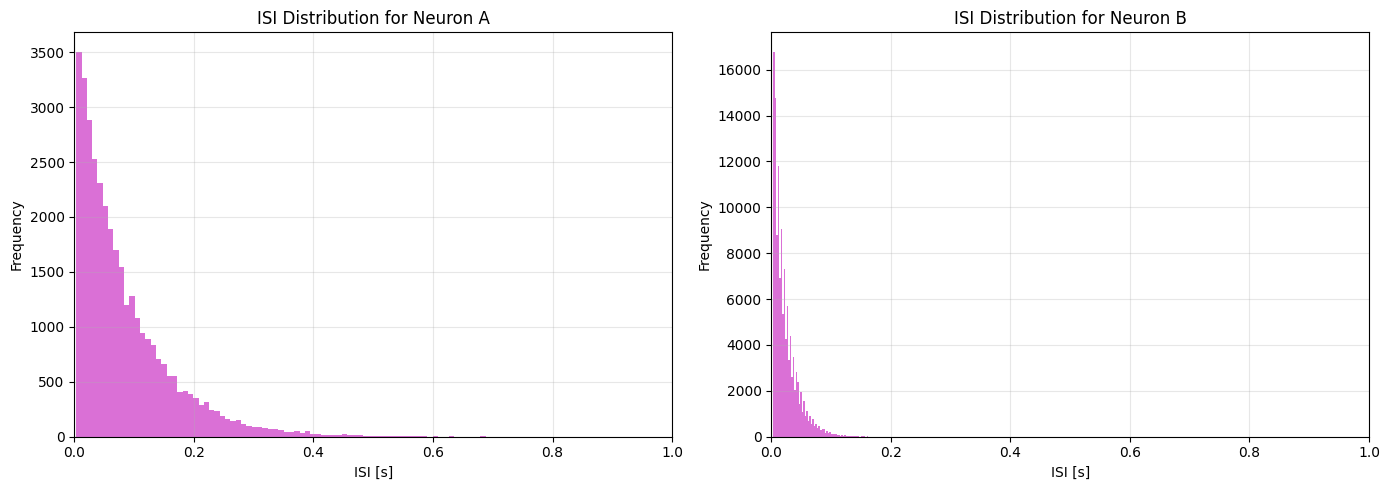

In [18]:
# Sampling frequency.
HZ = 1000

# Remove unnecessary columns to isolate the binary spike data.
drop_cols = ['trial_neuron', 'neuron', 'firing_rate', 'counts_1sec']
spike_data = df_spikes.drop(columns=drop_cols)

# Extract spike arrays for neurons A and B.
trials_A = spike_data[df_spikes['neuron'] == 'A'].values
trials_B = spike_data[df_spikes['neuron'] == 'B'].values

# Create a figure with 1 row and 2 columns to plot side-by-side.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Function to calculate and plot ISI.
def plot_ISI(df, ax, title):
  distances = []
  bin_size = 1 / HZ     # Size of one time bin in seconds (0.001s).

  for trial in df:
    # Find the timestamps where spikes occurred.
    spikes_index = [i for i, val in enumerate(trial) if val]

    # Calculate the time differences between consecutive spikes.
    dis = np.diff(spikes_index)
    dis_in_secs = dis * bin_size      # Convert ms to s.

    # Add the trial's intervals to the main list.
    distances.extend(dis_in_secs)

  # Plot the histogram using 100 bins for high resolution.
  ax.hist(distances, bins=100, color='orchid')

  # Add titles and labels for the specific subplot.
  ax.set_title(title)
  ax.set_xlabel('ISI [s]')
  ax.set_ylabel('Frequency')
  ax.set_xlim(0, 1)
  ax.grid(True, alpha=0.3)

# Call the function for both neurons.
plot_ISI(trials_A, axes[0], 'ISI Distribution for Neuron A')
plot_ISI(trials_B, axes[1], 'ISI Distribution for Neuron B')

plt.tight_layout()
plt.show()

**3.1.E - Raster Plots**

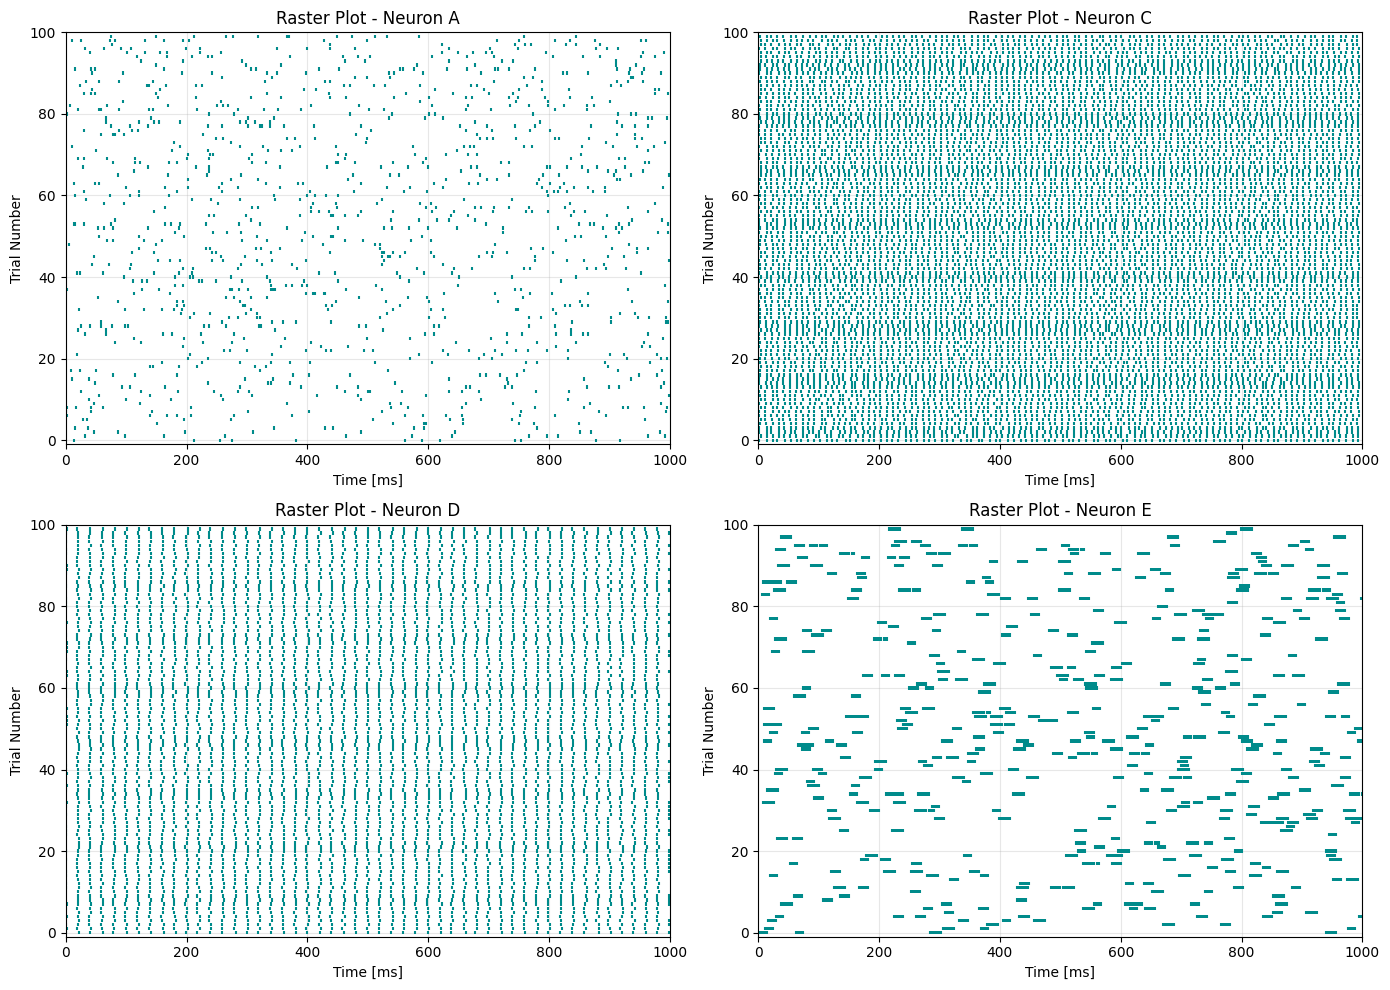

In [19]:
# Define the neurons to plot.
neurons_to_plot = ['A', 'C', 'D', 'E']

# Create a 2x2 grid of subplots, and flatten the matrix into 1D array to iterate easily.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, neuron in enumerate(neurons_to_plot):

  # Filter data for the specific neuron, and extract only the first 1000 ms.
  neuron_df = spike_data[df_spikes['neuron'] == neuron]
  first_sec_data = neuron_df.iloc[:, :1000]

  # Find the time indices where spikes occurred for each trial.
  spike_positions = [np.where(row == 1)[0] for _, row in first_sec_data.iterrows()]

  # Plot the spikes as vertical lines.
  axes[i].eventplot(spike_positions, linelengths=0.8, colors='darkcyan')

  # Add title, labels, and set axis limits.
  axes[i].set_title(f'Raster Plot - Neuron {neuron}')
  axes[i].set_xlabel('Time [ms]')
  axes[i].set_ylabel('Trial Number')

  axes[i].set_xlim(0, 1000)
  axes[i].set_ylim(-1, len(spike_positions))
  axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**3.1.G - PSTH plots**

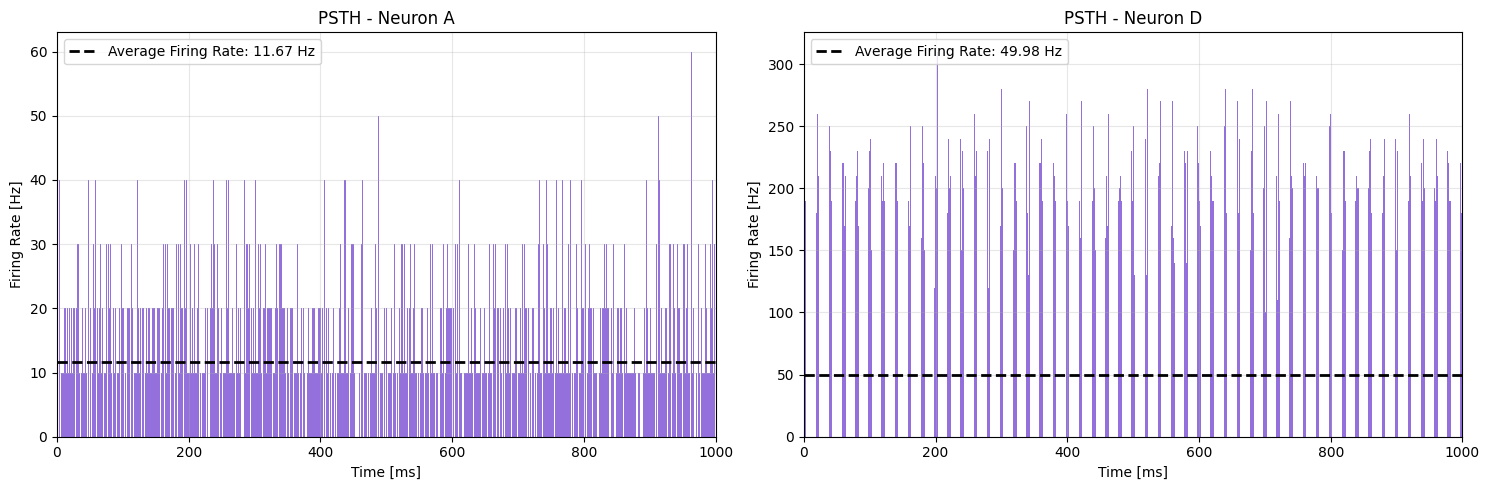

In [20]:
# Define experimental parameters.
num_trials = 100
bin_width_sec = 1 / HZ    # 1 ms bin width in seconds.

# Create a figure with 1 row and 2 columns for side-by-side plotting.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.flatten()

for i, neuron in enumerate(['A', 'D']):
  # Extract all trials for the current neuron.
  neuron_trials = spike_data[df_spikes['neuron'] == neuron].values

  # Slice only the first 1 second (1000 ms) of data.
  first_sec_data = neuron_trials[:, :HZ]
  hist_data = []

  # Collect all spike timestamps (in ms) across all trials for the first second.
  for trial in first_sec_data:
    spike_pos = np.where(trial == 1)[0]
    hist_data += list(spike_pos)

  # Calculate the overall average firing rate across the entire recording.
  total_spikes = np.sum(neuron_trials)
  avg_fr = total_spikes / (num_trials * duration)

  # Create weights to normalize the histogram Y-axis into Firing Rate (Hz).
  weights = np.ones_like(hist_data) / (num_trials * bin_width_sec)

  # Plot the PSTH.
  axes[i].hist(hist_data, bins=HZ, weights=weights, width=1.5, color='mediumpurple')

  # Add a line representing the overall average firing rate.
  axes[i].axhline(avg_fr, color='black', linestyle='--', linewidth=2, label=f'Average Firing Rate: {avg_fr:.2f} Hz')

  # Add titles and labels.
  axes[i].set_title(f'PSTH - Neuron {neuron}')
  axes[i].set_xlabel('Time [ms]')
  axes[i].set_ylabel('Firing Rate [Hz]')
  axes[i].legend(loc='upper left')
  axes[i].set_xlim(0, 1000)
  axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Part 3.2: Correlation Analysis

**3.2.A - Autocorrelation**

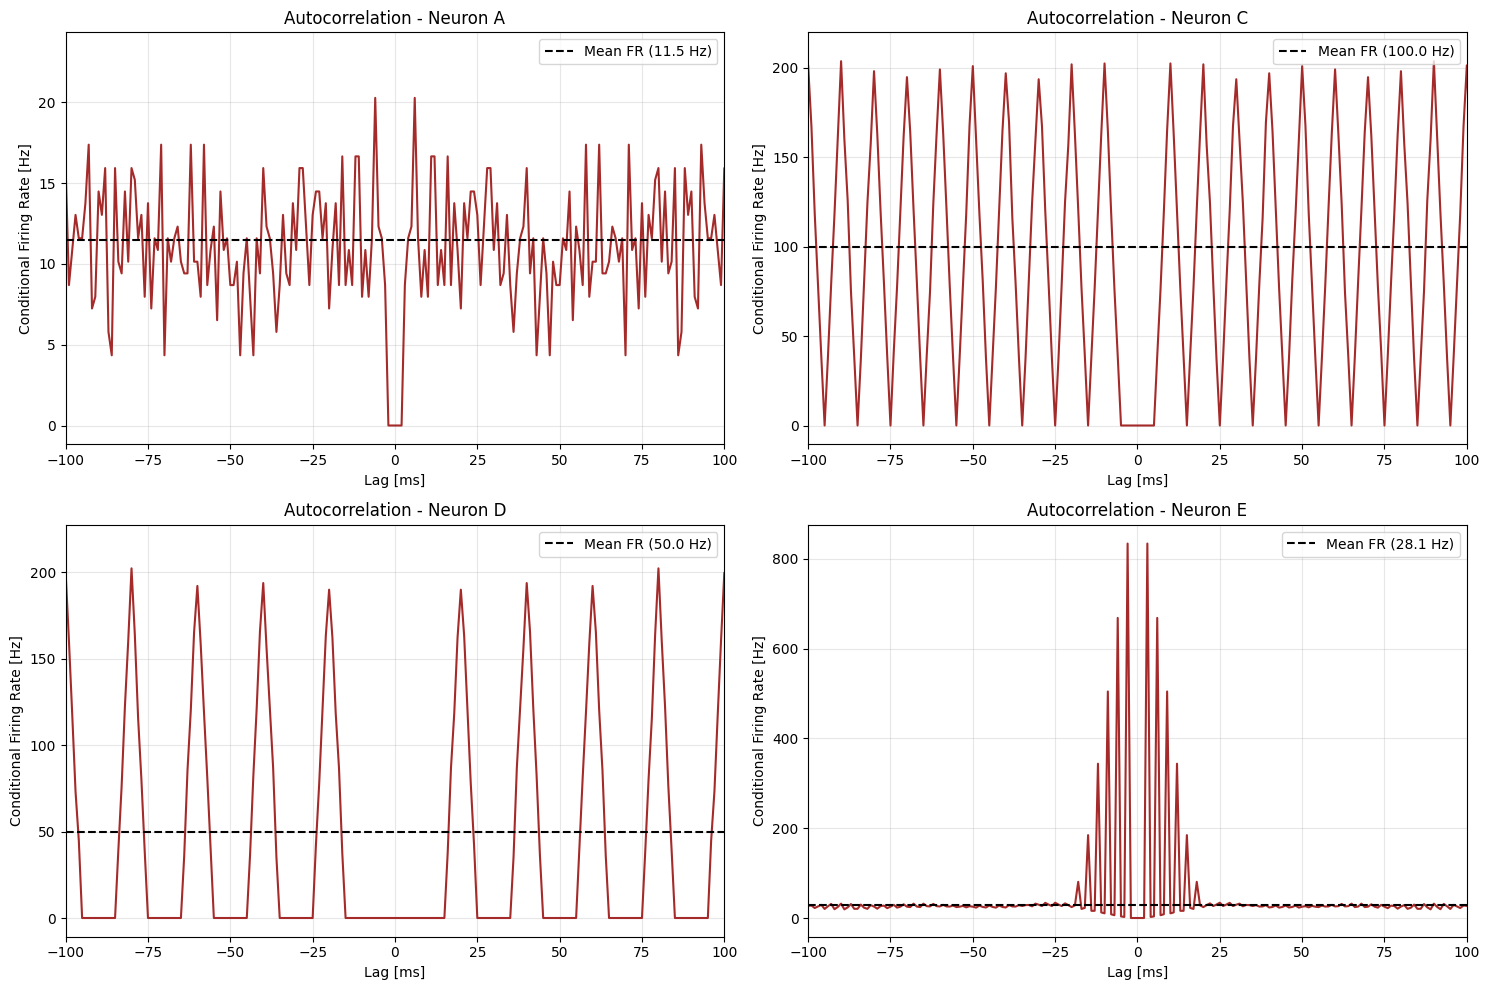

In [21]:
# Define neurons to analyze and calculate the number of samples in 2 minutes (120s).
neurons_to_plot = ['A', 'C', 'D', 'E']
two_mins_samples = 120 * HZ

# Create a 2x2 grid of subplots and flatten for easy iteration.
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, neuron in enumerate(neurons_to_plot):
  # Extract all trials for the specific neuron.
  neuron_df = spike_data[df_spikes['neuron'] == neuron].values

  # Flatten all trials into one continuous recording and keep only the first 2 minutes.
  flattened = neuron_df.flatten()
  data_2_mins = flattened[:two_mins_samples]

  # Count total spikes in this window.
  total_spikes = np.sum(data_2_mins)

  # Calculate autocorrelation efficiently using FFT.
  auto_corr = signal.correlate(data_2_mins, data_2_mins, mode='full', method='fft')

  # Generate the corresponding lag axis.
  lags = signal.correlation_lags(len(data_2_mins), len(data_2_mins), mode='full')

  # Normalize raw coincidences to firing rate.
  normalized = (auto_corr / total_spikes) * HZ

  # Manually zero out lag 0 to avoid distorting the plot's scale.
  center_idx = np.where(lags == 0)[0][0]
  normalized[center_idx] = 0

  # Calculate the overall mean firing rate.
  mean_fr = total_spikes / 120

  # Plot the autocorrelation function.
  axes[i].plot(lags, normalized, color='brown')
  axes[i].set_title(f'Autocorrelation - Neuron {neuron}')
  axes[i].set_xlabel('Lag [ms]')
  axes[i].set_ylabel('Conditional Firing Rate [Hz]')

  # Add the mean firing rate reference line and a legend.
  axes[i].axhline(mean_fr, color='black', linestyle='--', label=f'Mean FR ({mean_fr:.1f} Hz)')
  axes[i].legend(loc='upper right')

  # Zoom in on the central window (-100 ms to +100 ms).
  axes[i].set_xlim(-100, 100)
  axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**3.2.E - Cross Correlation (A vs B)**

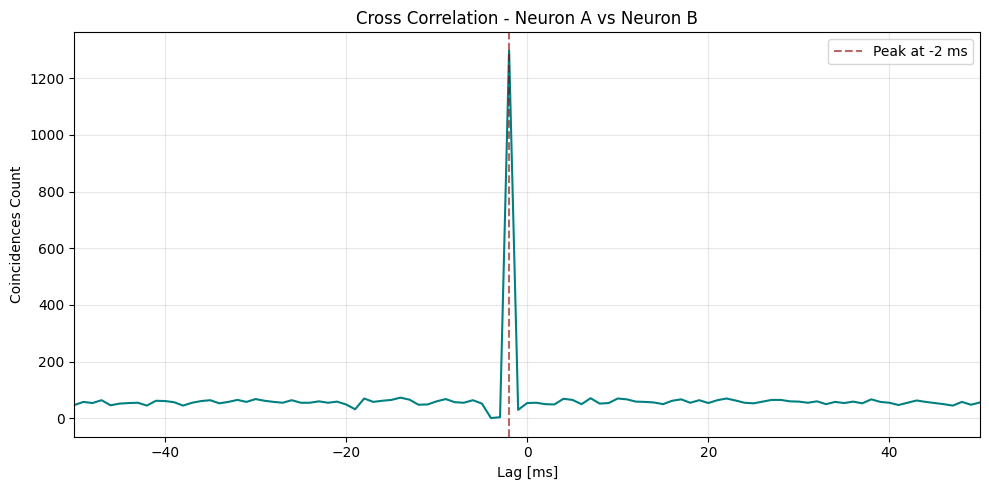

In [22]:
# Extract and flatten trials for neuron A, keeping only the first 2 minutes.
trials_A = spike_data[df_spikes['neuron'] == 'A'].values
data_A = trials_A.flatten()[:two_mins_samples]

# Reapeat for neuron B.
trials_B = spike_data[df_spikes['neuron'] == 'B'].values
data_B = trials_B.flatten()[:two_mins_samples]

# Calculate cross-correlation using FFT for efficiency.
cross_corr = signal.correlate(data_A, data_B, mode='full', method='fft')
lags = signal.correlation_lags(len(data_A), len(data_B), mode='full')

# Find the lag (in ms) where the peak occurs.
peak_idx = np.argmax(cross_corr)
peak_lag = lags[peak_idx]

# Plot the cross-correlation result.
plt.figure(figsize=(10, 5))
plt.plot(lags, cross_corr, color='teal')
plt.title('Cross Correlation - Neuron A vs Neuron B')
plt.xlabel('Lag [ms]')
plt.ylabel('Coincidences Count')

# Add a vertical dashed line to highlight the exact lag of the peak.
plt.axvline(x=peak_lag, color='darkred', linestyle='--', alpha=0.6, label=f'Peak at {peak_lag} ms')
plt.legend()

# Zoom in on a narrow window.
plt.xlim(-50, 50)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**3.2.G - Cross Correlation (C vs D)**

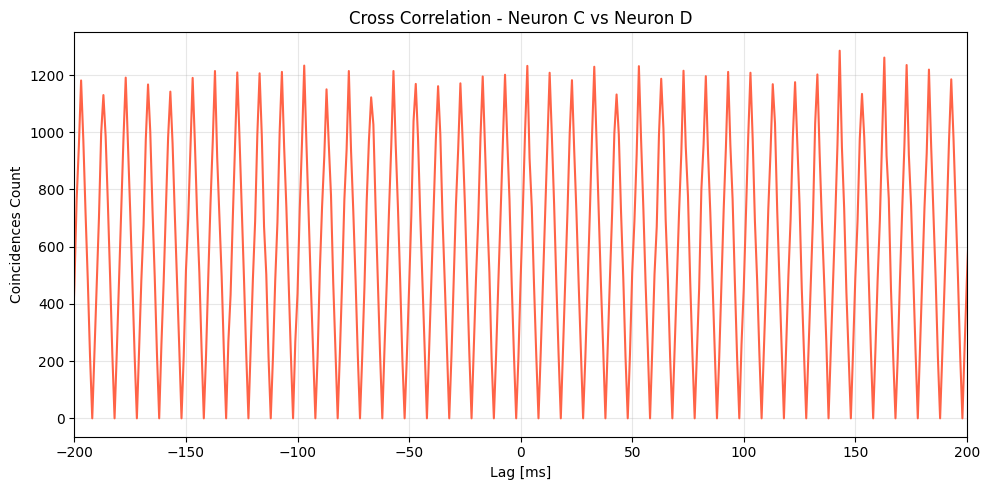

In [23]:
# Extract and flatten trials for neuron A, keeping only the first 2 minutes.
trials_C = spike_data[df_spikes['neuron'] == 'C'].values
data_C = trials_C.flatten()[:two_mins_samples]

# Repeating for neuron D.
trials_D = spike_data[df_spikes['neuron'] == 'D'].values
data_D = trials_D.flatten()[:two_mins_samples]

# Calculate cross-correlation using FFT for efficiency.
cross_corr = signal.correlate(data_C, data_D, mode='full', method='fft')
lags = signal.correlation_lags(len(data_C), len(data_D), mode='full')

# Plot the cross-correlation result.
plt.figure(figsize=(10, 5))
plt.plot(lags, cross_corr, color='tomato')
plt.title('Cross Correlation - Neuron C vs Neuron D')
plt.xlabel('Lag [ms]')
plt.ylabel('Coincidences Count')

# Zoom in on a wider window to observe the oscillatory pattern.
plt.xlim(-200, 200)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()